In [21]:
%load_ext autoreload
%autoreload 2
import numpy as np

from metanet_calibration.param_loader import METANET_Params
from metanet_calibration.ipopt_optimization import run_calibration, mape, smooth_inflow
from metanet_calibration.metanet_dynamics import run_metanet_sim
from metanet_calibration.data_processing import plot_simulation_comparison


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
combined_bounds = {
    "eta_high": (1.0, 90.0),
    "tau": (1.0 / 3600, 60.0 / 3600),
    "K": (1.0, 50.0),
    "rho_crit": (1e-2, 100),
    "v_free": (50, 150),
    "a": (0.01, 10),
    "beta": (1e-3, 0.9),
    "r_inflow": (1e-3, 2000),
}

initializations = None

In [23]:
# Ground Truth Data

q_hat = np.load("example_i24_data/q_hat.npy")
rho_hat = np.load("example_i24_data/rho_hat.npy")
rho_hat = np.where(rho_hat == 0.0, 1e-3, rho_hat)
q_hat = np.where(q_hat == 0.0, 1e-3, q_hat)
v_hat = q_hat / rho_hat # Or you could load v_hat if you have it

T = 10 / 3600
l = 0.4
num_calibrated_segments = 14

In [24]:
# Load lanes and ramps

lame_mapping = np.load("example_i24_data/lane_mapping.npy")
on_ramp = np.load("example_i24_data/on_ramp_mapping.npy")
off_ramp = np.load("example_i24_data/off_ramp_mapping.npy")

In [25]:
np.random.seed(1)


include_ramping = True
time_varying_ramping = True
RESULTS_DIR = "i24_11_30_results"
results = run_calibration(
    rho_hat,
    q_hat,
    T,
    l,
    num_calibrated_segments=num_calibrated_segments,
    include_ramping=include_ramping,
    smoothing=True,
    lane_mapping = lame_mapping,
    on_ramp_mapping = on_ramp,
    off_ramp_mapping = off_ramp,
    time_varying_ramping = True,
    bounds = combined_bounds,
    initialization = initializations
    
)

Calibrating segments [1:15) out of 16
360 14
(360, 1)
(360, 1)
[4.         4.         4.         4.35393916 5.         5.
 5.         5.         4.86074856 4.         4.         4.05066495
 4.50709814 4.        ]
Using custom bounds from input
'pyomo.core.base.var.IndexedVar'>) on block unknown with a new Component
(type=<class 'pyomo.core.base.var.IndexedVar'>). This is usually indicative of
a modelling error. To avoid this warning, use block.del_component() and
block.add_component().
'pyomo.core.base.var.IndexedVar'>) on block unknown with a new Component
(type=<class 'pyomo.core.base.var.IndexedVar'>). This is usually indicative of
a modelling error. To avoid this warning, use block.del_component() and
block.add_component().
Ipopt 3.14.19: max_iter=20000
acceptable_constr_viol_tol=1e-30
constr_viol_tol=1e-15


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is release

In [26]:
# Save data
import os
if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)
np.save(f"{RESULTS_DIR}/upstream_flow.npy", q_hat[:, 0])
np.save(f"{RESULTS_DIR}/downstream_density.npy", rho_hat[:, -1])

tau_array = results["tau"]
K_array = results["K"]
eta_high_array = results["eta_high"]
rho_crit_array = results["rho_crit"]
v_free_array = results["v_free"]
a_array = results["a"]
num_lanes_array = results["num_lanes"]
beta_array = results["beta"]
r_inflow_array = results["r_inflow"]

# Save everything
v_pred_array = results["v_pred"]
rho_pred_array = results["rho_pred"]
q_array = v_pred_array * rho_pred_array
np.save(f"{RESULTS_DIR}/tau.npy", tau_array)
np.save(f"{RESULTS_DIR}/K.npy", K_array)
np.save(f"{RESULTS_DIR}/eta_high.npy", eta_high_array)
np.save(f"{RESULTS_DIR}/rho_crit.npy", rho_crit_array)
np.save(f"{RESULTS_DIR}/v_free.npy", v_free_array)
np.save(f"{RESULTS_DIR}/a.npy", a_array)
np.save(f"{RESULTS_DIR}/num_lanes.npy", num_lanes_array)
np.save(f"{RESULTS_DIR}/q_pred.npy", q_array)
np.save(f"{RESULTS_DIR}/v_pred.npy", v_pred_array)
np.save(f"{RESULTS_DIR}/rho_pred.npy", rho_pred_array)
np.save(f"{RESULTS_DIR}/beta_array.npy", beta_array)
np.save(f"{RESULTS_DIR}/r_inflow_array.npy", r_inflow_array)

In [27]:
print("Simulating with calibrated parameters...")

# Remember we calibrated to interior segments only

initial_density = rho_hat[0, 1:-1]
initial_velocity = v_hat[0, 1:-1]
downstream_density = smooth_inflow(rho_hat[:, -1])
data_inflow = smooth_inflow(q_hat[:, 0])

# Initial conditions: (total_density, velocity, inflow, queue)
init_traffic_state = (initial_density, initial_velocity, data_inflow[0], 0) # queue can be 0 since we're using ground truth data
RESULTS_DIR = "i24_11_30_results"
# Get parameters
params = METANET_Params(path=RESULTS_DIR, num_segments=num_calibrated_segments).get_params()

rho_sim_new, v_sim_new, queue_sim, tts_sim = run_metanet_sim(
    T, 
    l, 
    init_traffic_state,
    data_inflow,
    downstream_density,
    params,
    vsl_speeds=None,
    lanes={i: lame_mapping[i+1] for i in range(num_calibrated_segments)}, # lane_mapping is of shape (num_calibrated_segments+2,)
    plotting=True,
    real_data=True
)

Simulating with calibrated parameters...
Loaded r_inflow_array.npy
(360, 14)


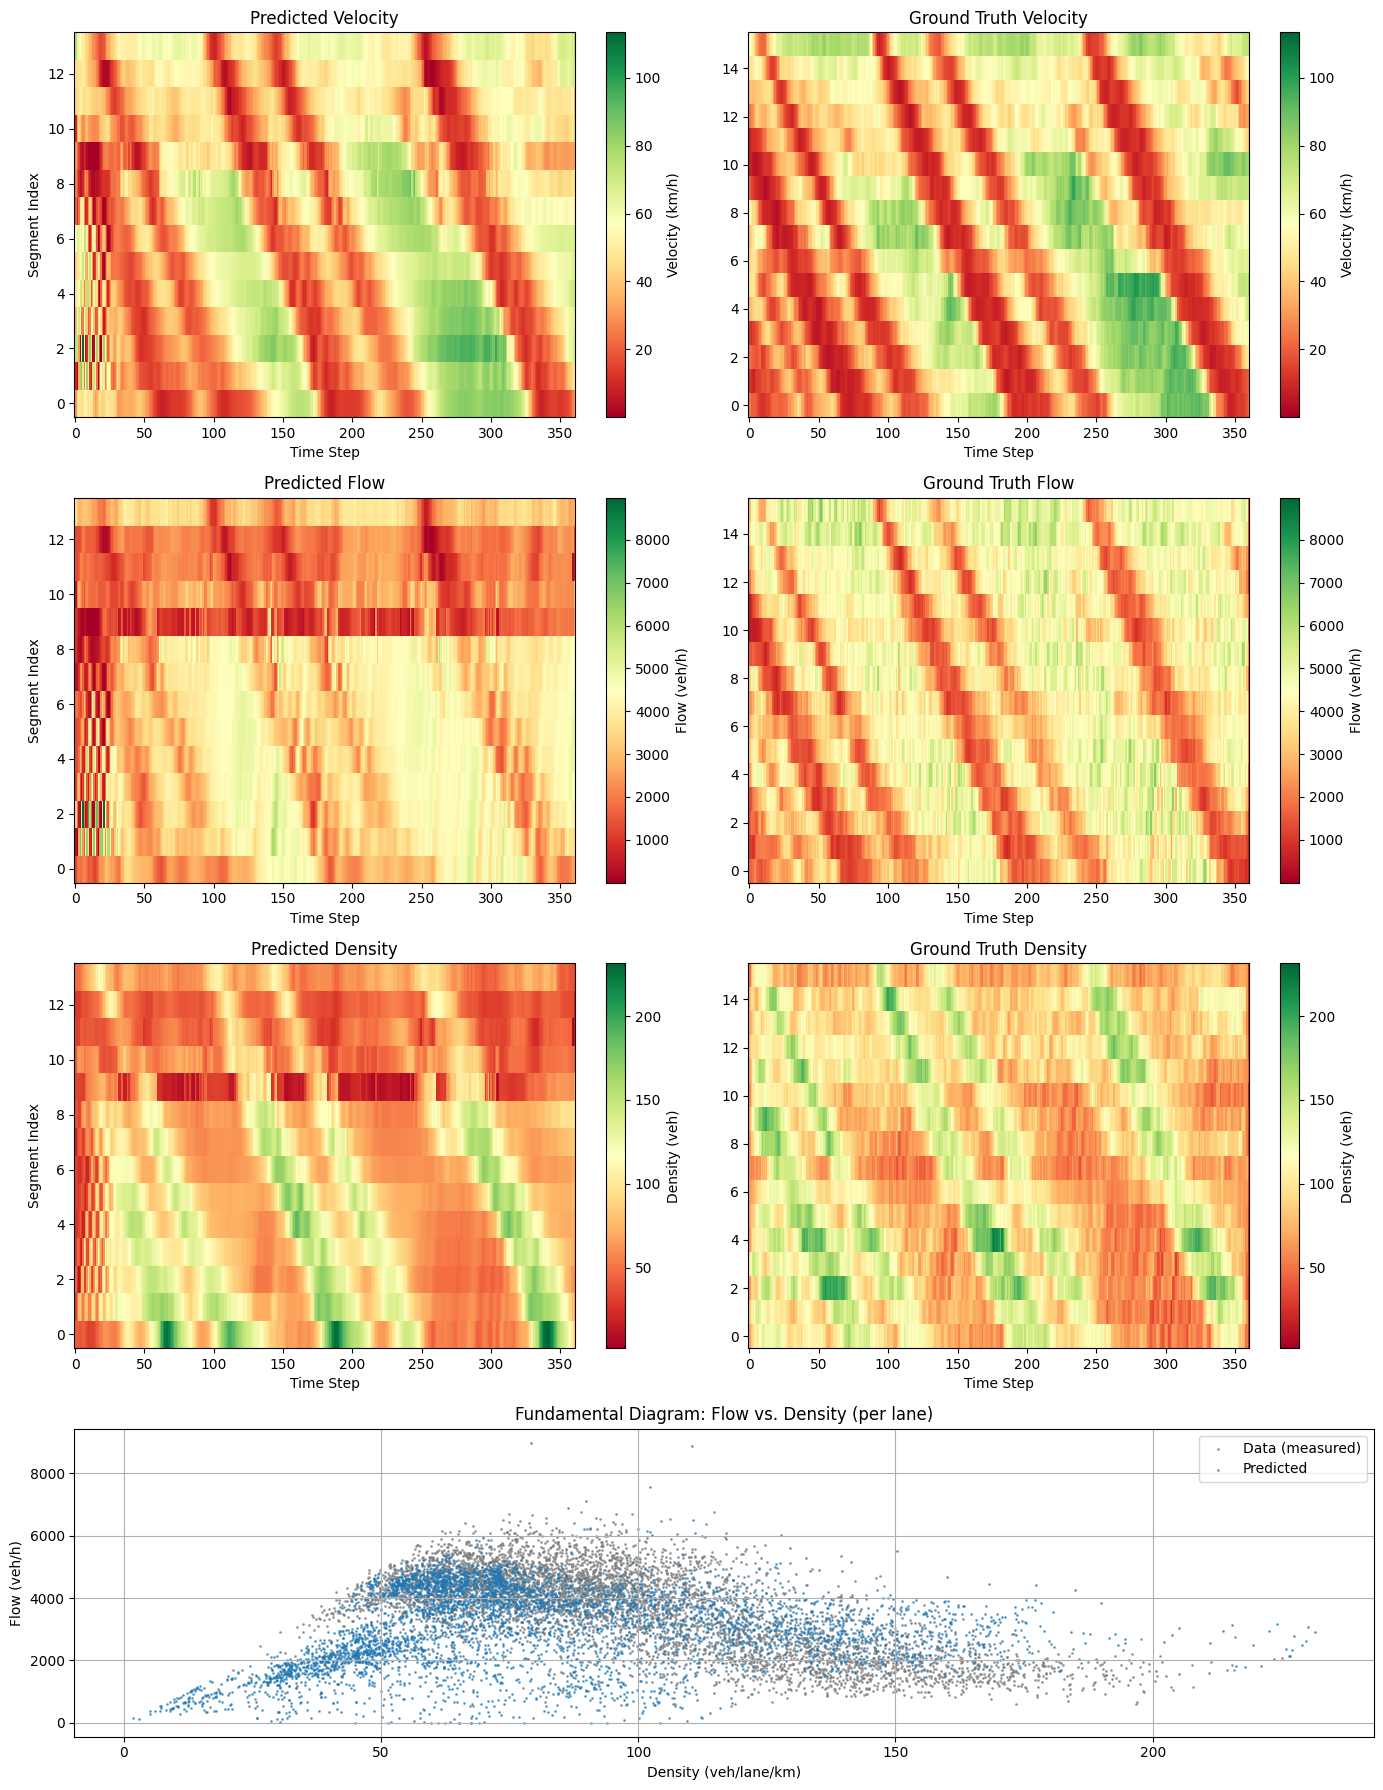

rho mape 27.87726374299942
q mape 35.11623077446392
v mape 26.789926014227746


In [28]:
plot_simulation_comparison(rho_sim_new, v_sim_new, rho_hat, v_hat, q_true=q_hat, include_fd=True, save_path=None)
q_sim_new = v_sim_new*rho_sim_new
print("rho mape", mape(rho_hat[:, 1:-1], rho_sim_new[:-1,:]))
print("q mape", mape(q_hat[:, 1:-1], q_sim_new[:-1,:]))
print("v mape", mape(v_hat[:, 1:-1], v_sim_new[:-1,:]))